In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

TS_synth_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    TS_synth_cache[path] = (T + S).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

TS_meas_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    TS_meas_cache[path] = (T + S).astype(np.uint8)

100%|██████████| 1345/1345 [01:13<00:00, 18.28it/s] 


In [6]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

T_synth_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    T_synth_cache[path] = (T).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

T_meas_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    T_meas_cache[path] = (T).astype(np.uint8)

100%|██████████| 1345/1345 [01:06<00:00, 20.17it/s]


In [7]:
TS_no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0),
         MaskedAugmentation(augmentation=identity, fill=0, mask_cache=TS_synth_cache),
            NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

T_no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0),
         MaskedAugmentation(augmentation=identity, fill=0, mask_cache=T_synth_cache),
            NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

In [8]:
TS_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation = GaussianNoise(mu = 0, sigma = 0.3), 
                           fill = 0, 
                           mask_cache = TS_synth_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

TS_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation = identity, fill = 0, mask_cache = TS_meas_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

T_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation = GaussianNoise(mu = 0, sigma = 0.3), 
                           fill=0, 
                           mask_cache=T_synth_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

T_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation = identity, fill=0, mask_cache=T_meas_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

In [7]:
train_ds = T_synth_ds
test_ds = T_meas_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [8]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = seed_lst[6:]

train_loss = []
# val_loss = []
train_acc =[]
# val_acc = []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        # "val_loss" : [],
        "train_acc": [],
        # "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    # val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    # val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_only/rn18_seed{seed}_b16.pth"))

    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
    
train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Training Run 0: seed 849
Epoch 0
First layer mean: -0.000448
train Loss: 0.8242428406 Acc: 0.7174721190
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.1658541875 Acc: 0.9486988848
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.1360571604 Acc: 0.9576208178
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.1252389741 Acc: 0.9687732342
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0903863857 Acc: 0.9732342007
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0511100806 Acc: 0.9828996283
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0328667388 Acc: 0.9910780669
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0650123025 Acc: 0.9814126394
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0722838236 Acc: 0.9799256506
Epoch 8 LR: 0.0002985050
Epoch 9
train Loss: 0.0765340050 Acc: 0.9784386617
Epoch 9 LR: 0.0002981551
Epoch 10
train Loss: 0.0441623796 Acc: 0.9866171004
Epoch 10 LR: 0.0002977686
Epoch 11
train Loss: 0.0327130887 Acc: 0.9933085502
Epoch 11 LR: 0.0002973457
Epoch 12
train Loss: 0.02818994

# Results

## Target + Shadow

### Fill = 0

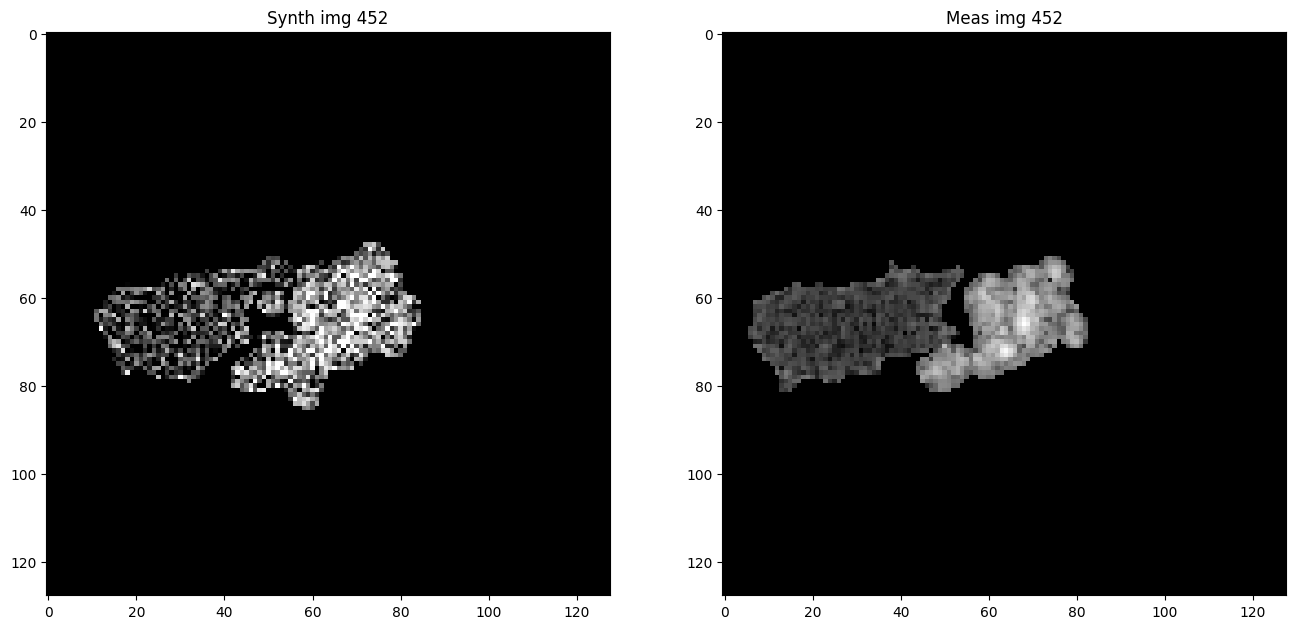

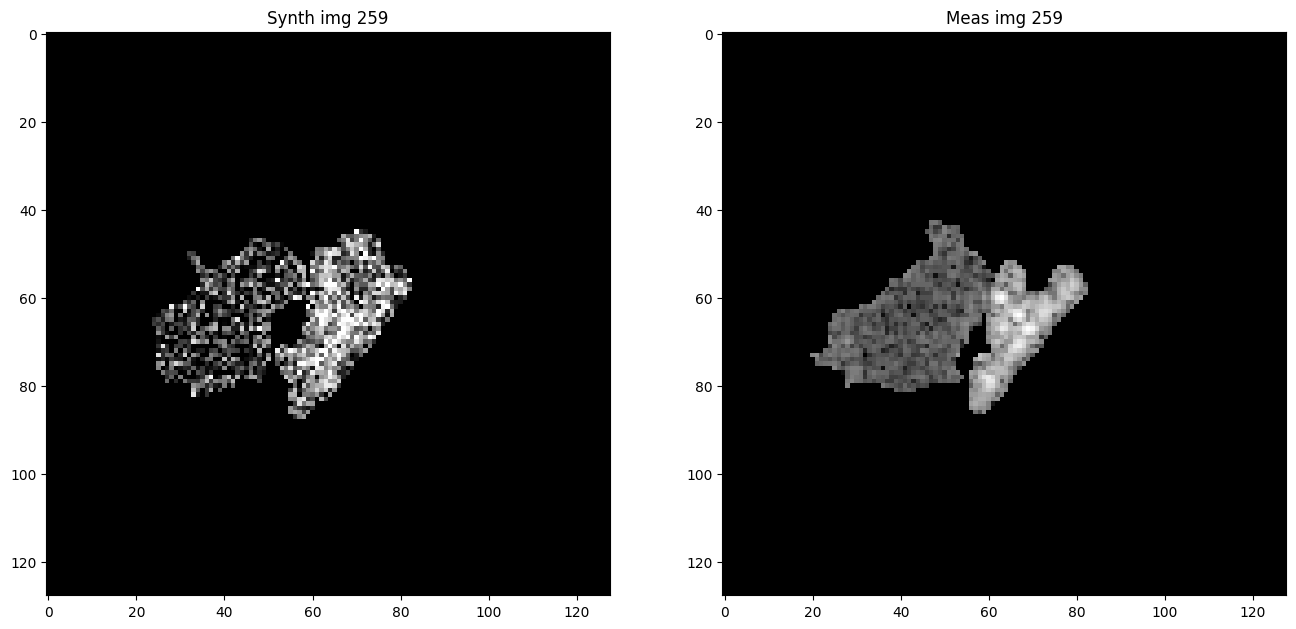

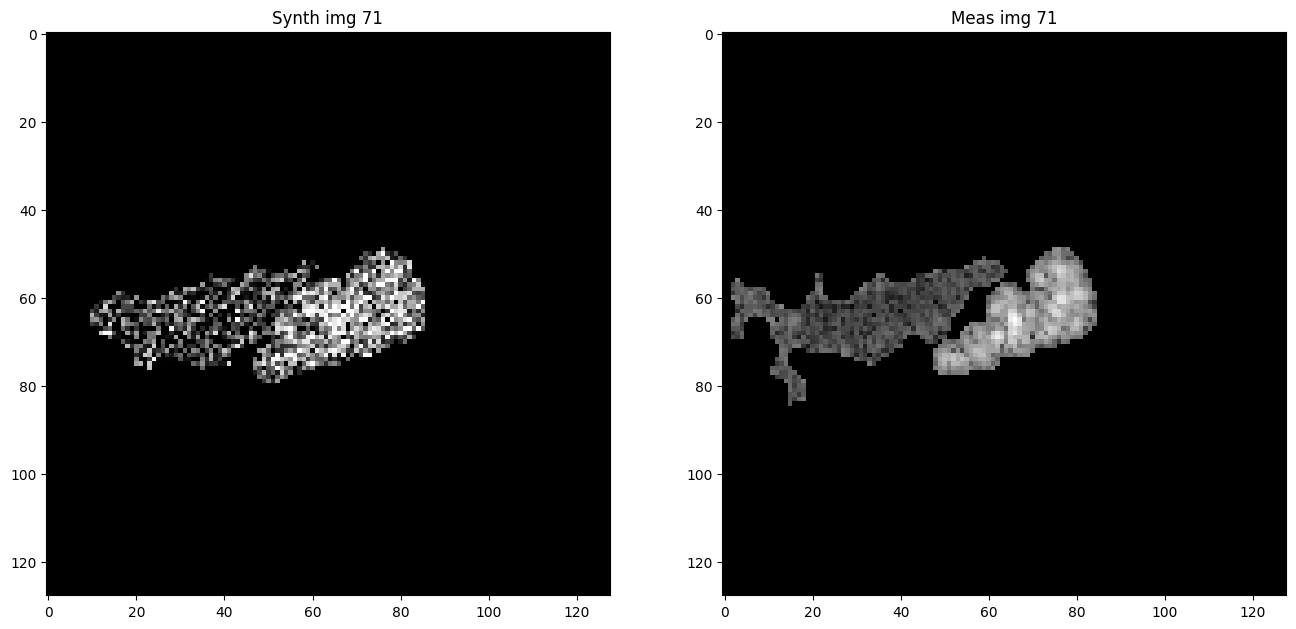

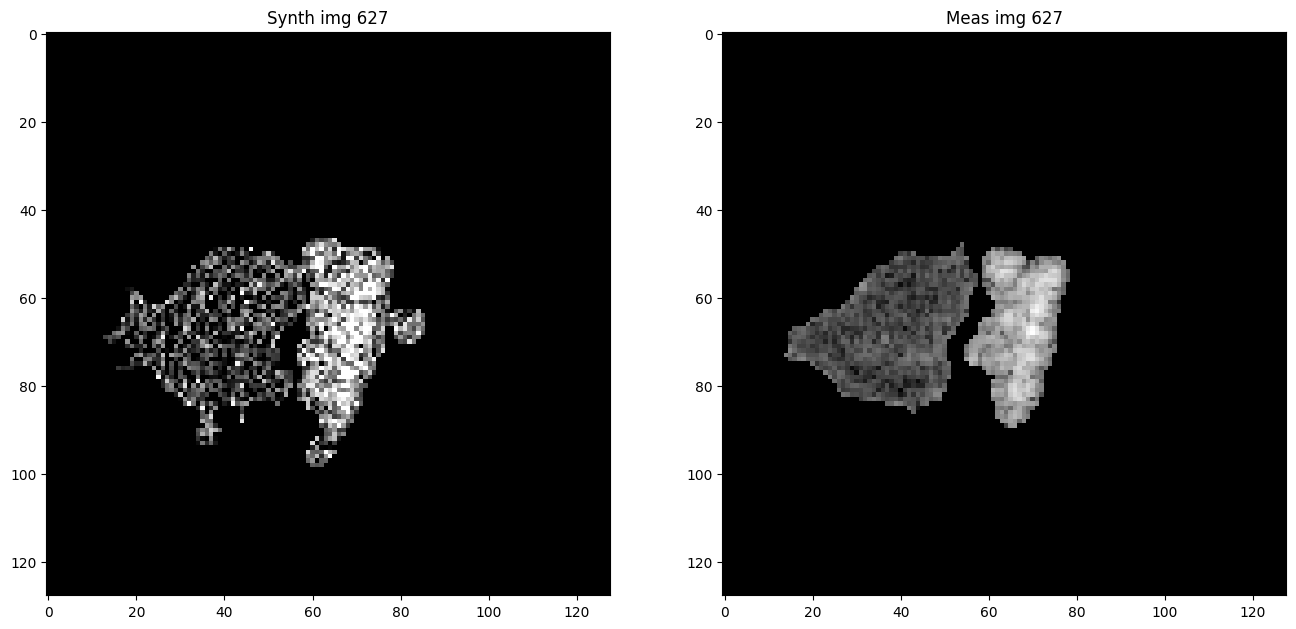

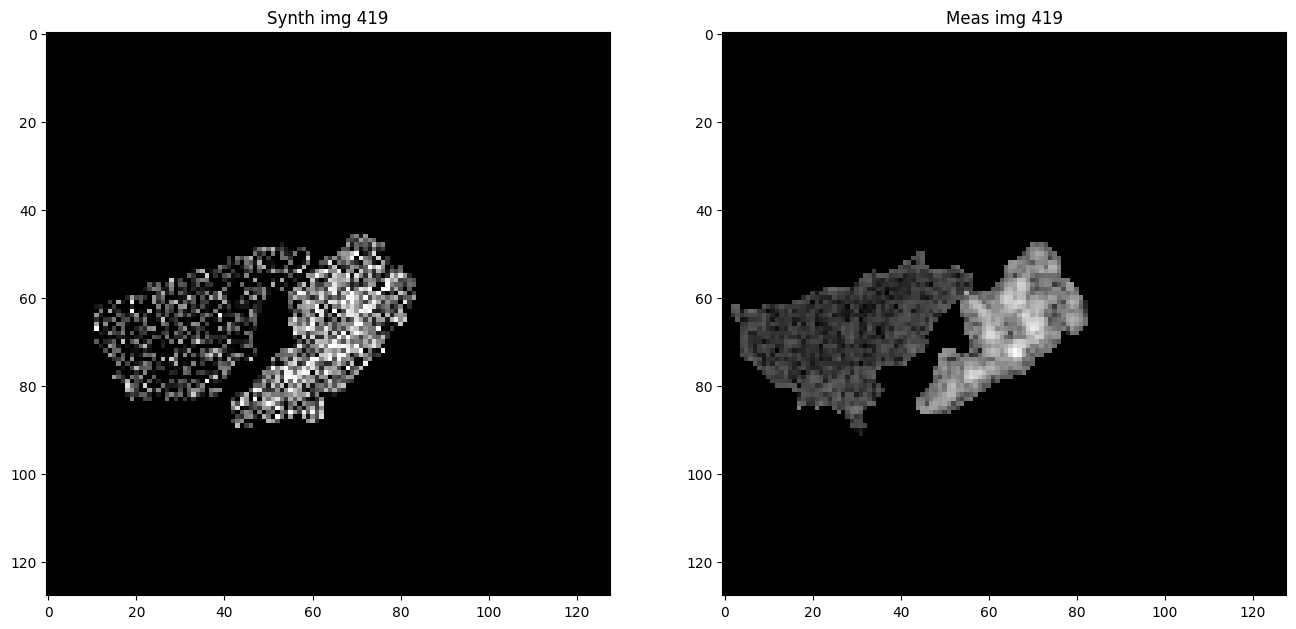

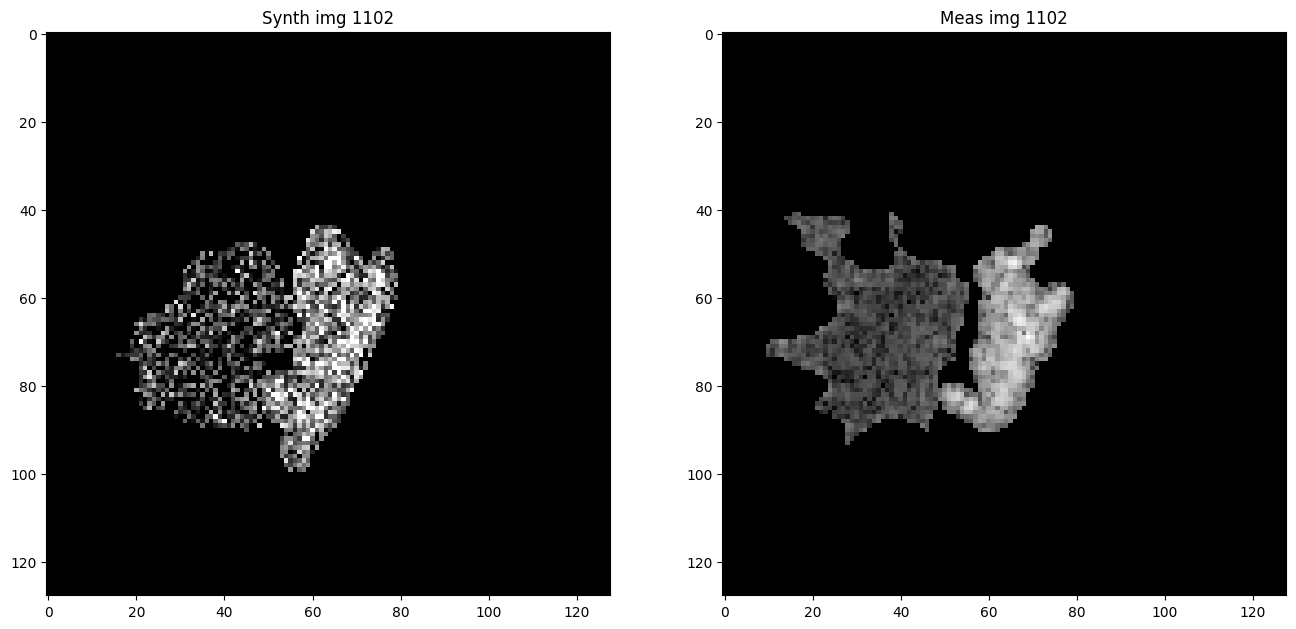

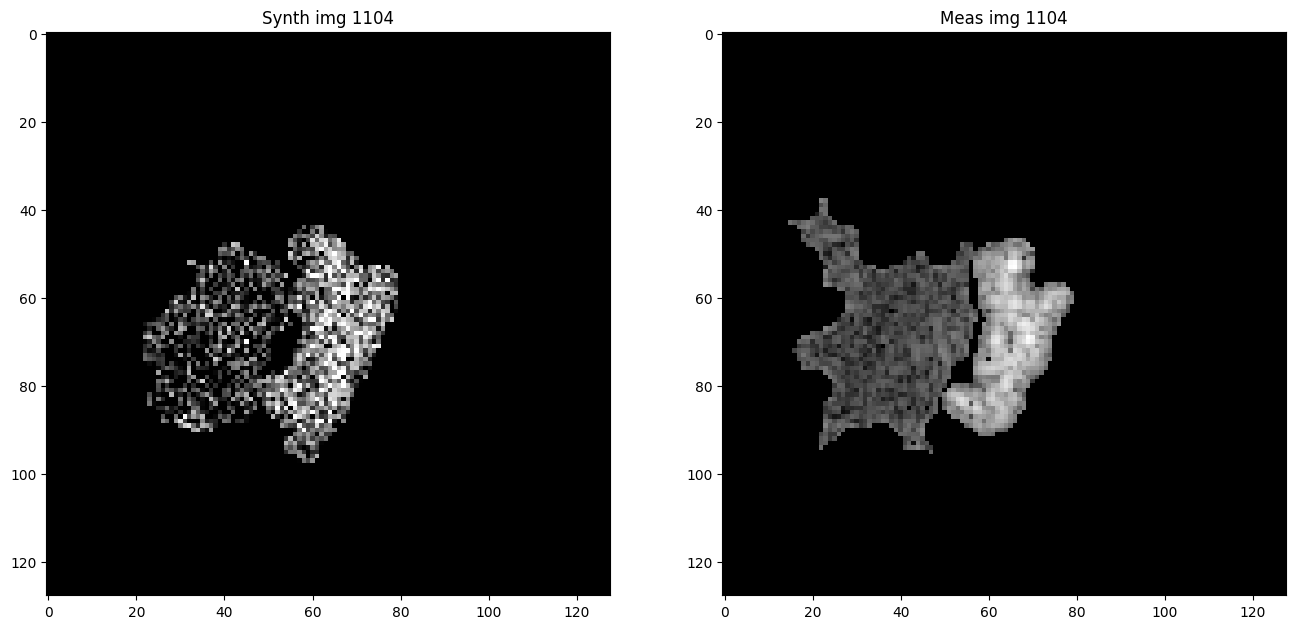

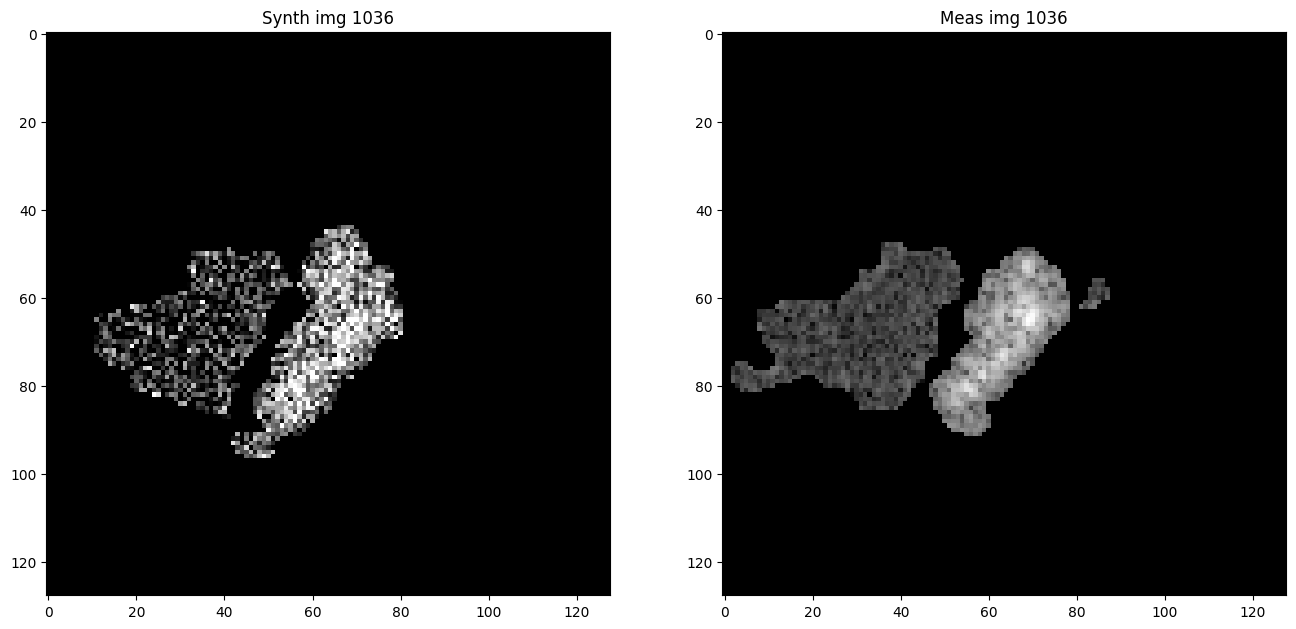

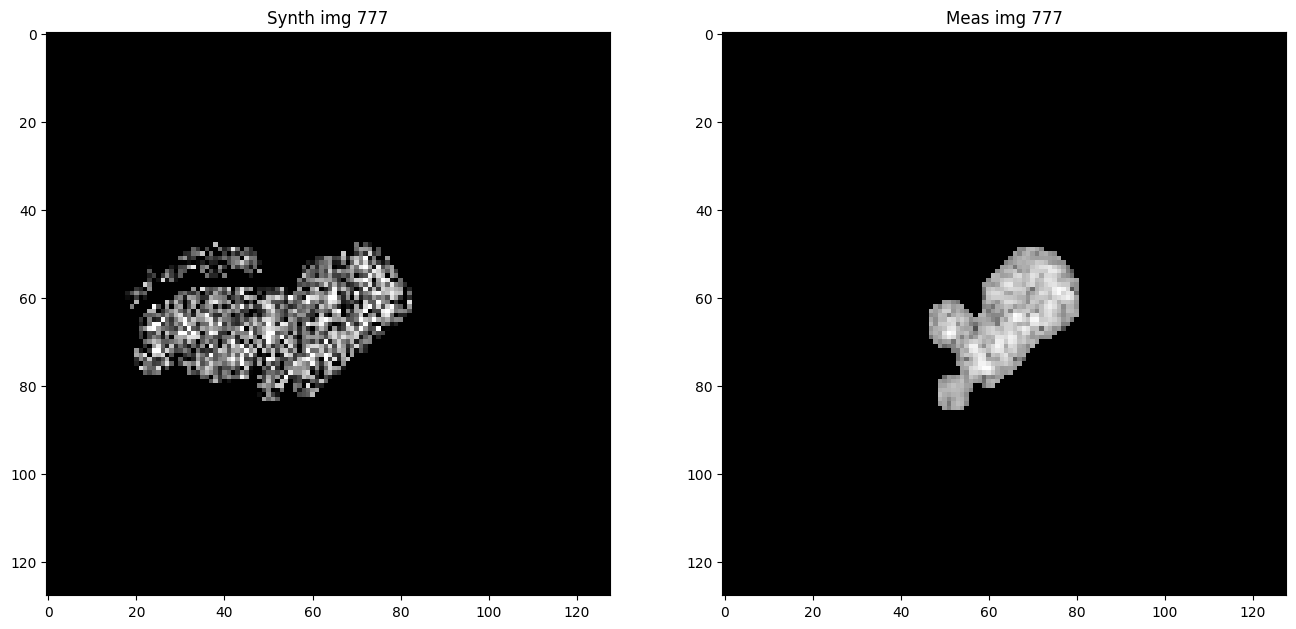

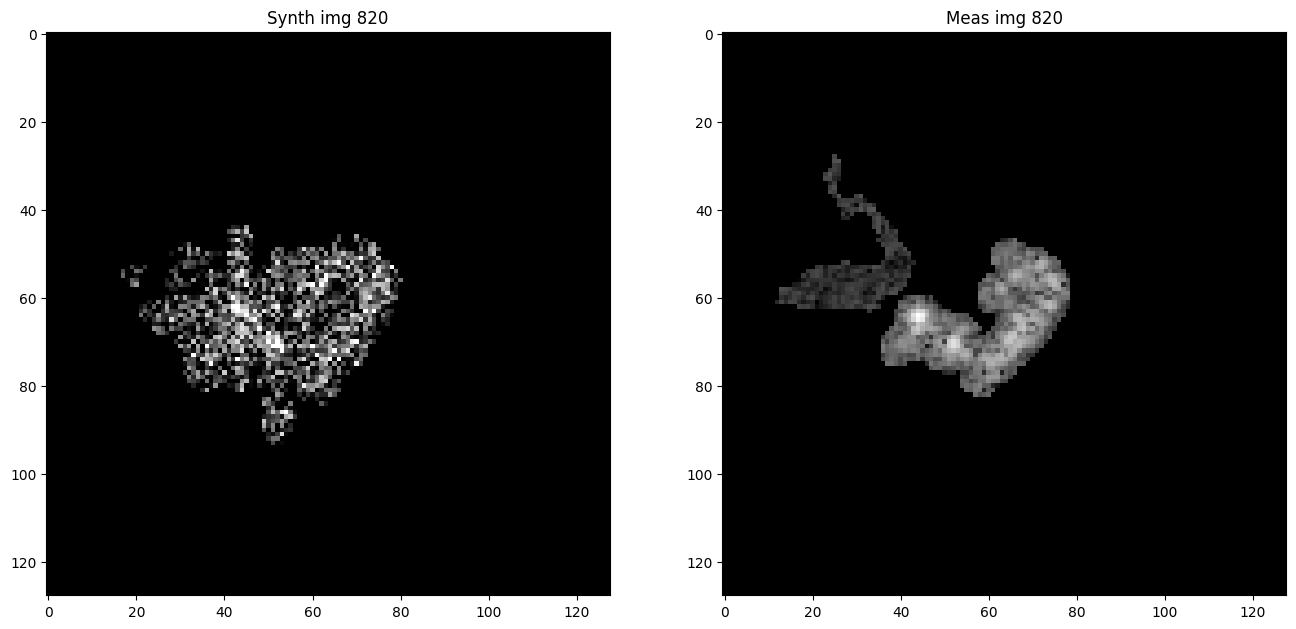

In [9]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = TS_synth_ds[i][0][0]
    meas_img = TS_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [10]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_shadow/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(TS_meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.7926
Evaluating Run 1: Seed 42
Test Accuracy: 0.8268
Evaluating Run 2: Seed 100
Test Accuracy: 0.7926
Evaluating Run 3: Seed 123
Test Accuracy: 0.8335
Evaluating Run 4: Seed 666
Test Accuracy: 0.8119
Evaluating Run 5: Seed 777
Test Accuracy: 0.8126
Evaluating Run 6: Seed 849
Test Accuracy: 0.8327
Evaluating Run 7: Seed 1000
Test Accuracy: 0.8164
Evaluating Run 8: Seed 1111
Test Accuracy: 0.8164
Evaluating Run 9: Seed 1234
Test Accuracy: 0.8401


In [11]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 79.2565
Max: 84.0149
Avg, Std: 81.7546, 1.5447


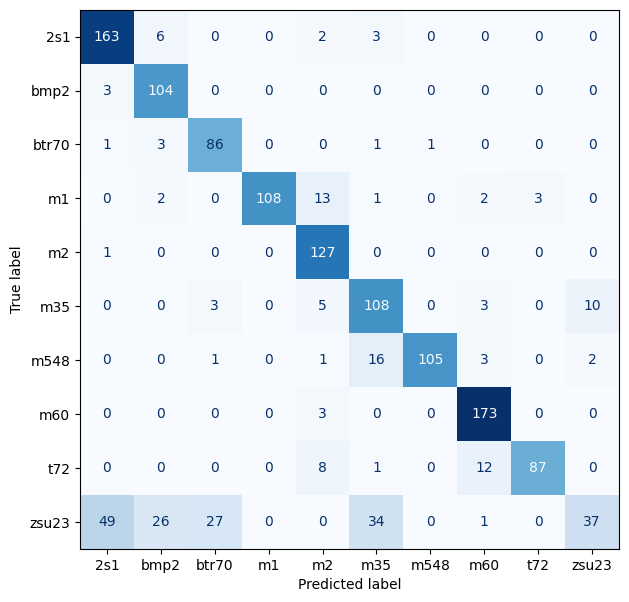

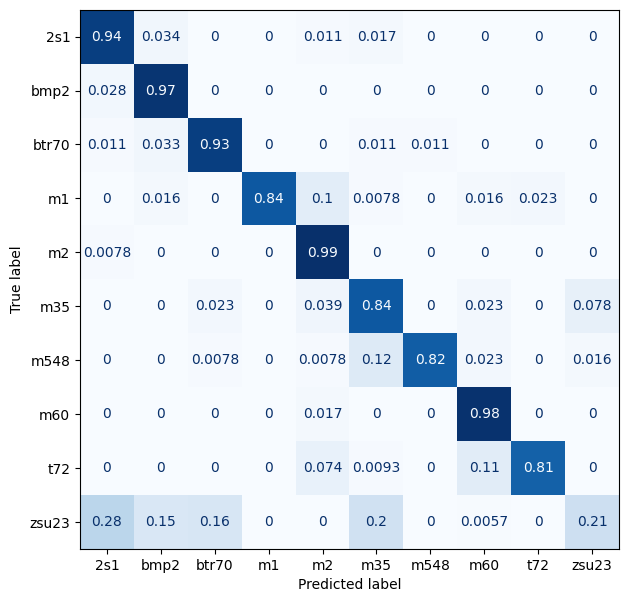

In [8]:
train_ds = TS_synth_ds
test_ds = TS_meas_ds

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_shadow/rn18_seed1000_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

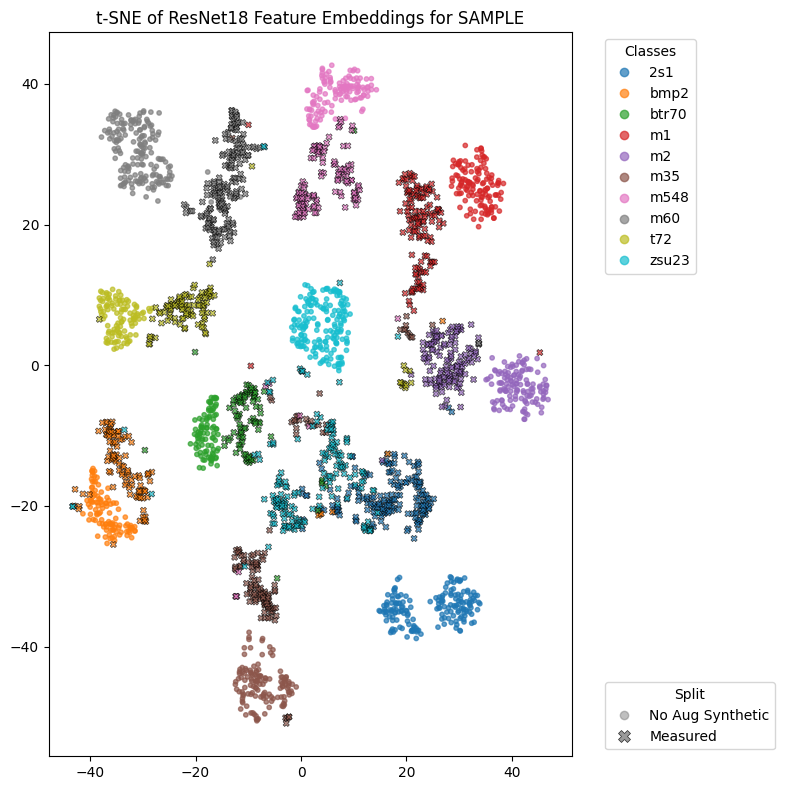

In [9]:
train_ds = TS_synth_ds
test_ds = TS_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_shadow/rn18_seed1000_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-27 11:30:01.839] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


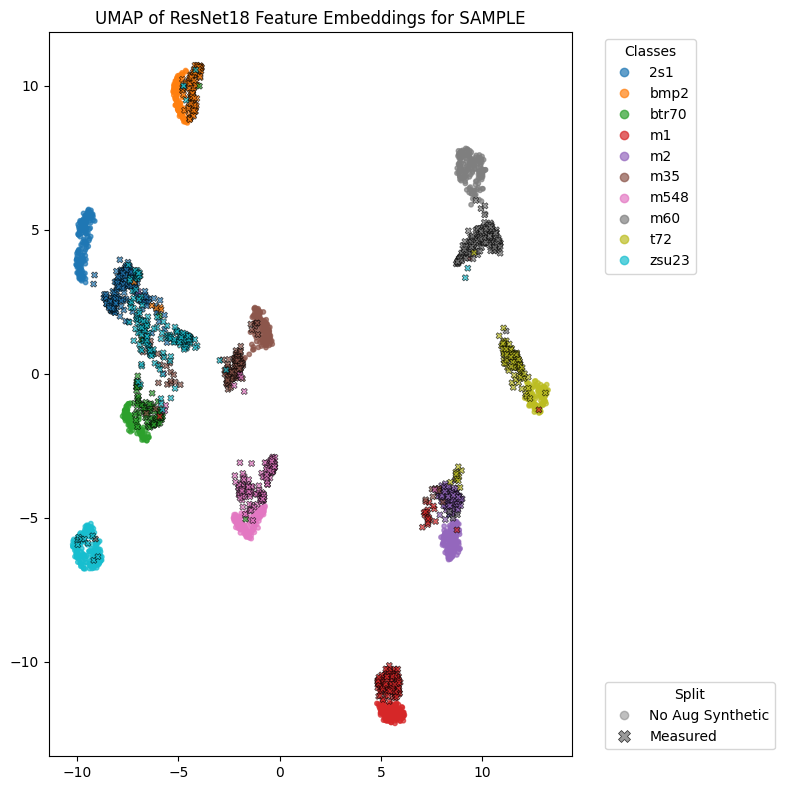

In [10]:
train_ds = TS_synth_ds
test_ds = TS_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_shadow/rn18_seed1000_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
    metric = "cosine"
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [9]:
seed = 1000
set_seed(seed)

device = torch.device("cuda:0")
torch.cuda.set_device(device)

# ── Model ────────────────────────────────────────────────────────────────────
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(no_aug_synth_ds.class_to_idx))
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_shadow/rn18_seed1000_b16.pth"),
    map_location=device
))
new_model = new_model.to(device).eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1]).to(device).eval()

# ── SSR aug synth — 200 epoch accumulation ───────────────────────────────────
SSR_synth_loader = DataLoader(
    TS_synth_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_synth = len(TS_synth_ds)
SSR_synth_feats_gpu  = torch.zeros(200 * n_synth, 512, device=device)
SSR_synth_labels_gpu = torch.zeros(200 * n_synth, dtype=torch.long, device=device)

idx = 0
for epoch in tqdm(range(200), leave=False, position=0, desc="Epochs"):
    with torch.no_grad():
        for inputs, targets in tqdm(SSR_synth_loader, leave=False, position=1, desc="Batches"):
            inputs = inputs.to(device)
            feats = feature_extractor(inputs).view(inputs.size(0), -1)
            bs = feats.size(0)
            SSR_synth_feats_gpu[idx:idx+bs]  = feats
            SSR_synth_labels_gpu[idx:idx+bs] = targets.to(device)
            idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

SSR_synth_feats  = SSR_synth_feats_gpu.cpu().numpy()
SSR_synth_labels = SSR_synth_labels_gpu.cpu().numpy()

# ── no aug synth — single pass ───────────────────────────────────────────────────────
synth_loader = DataLoader(
    TS_no_aug_synth_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(TS_no_aug_synth_ds)
synth_feats_gpu  = torch.zeros(n_no_aug_synth, 512, device=device)
synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(synth_loader, leave=False, position=1, desc="Batches"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        synth_feats_gpu[idx:idx+bs]  = feats
        synth_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

synth_feats  = synth_feats_gpu.cpu().numpy()
synth_labels = synth_labels_gpu.cpu().numpy()

# ── meas — single pass ───────────────────────────────────────────────────────
meas_loader = DataLoader(
    TS_meas_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_meas = len(TS_meas_ds)
meas_feats_gpu  = torch.zeros(n_meas, 512, device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(meas_loader, leave=False, desc="Meas"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        meas_feats_gpu[idx:idx+bs]  = feats
        meas_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

meas_feats  = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

[2026-05-28 07:41:11.553] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-05-28 07:41:11.553] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


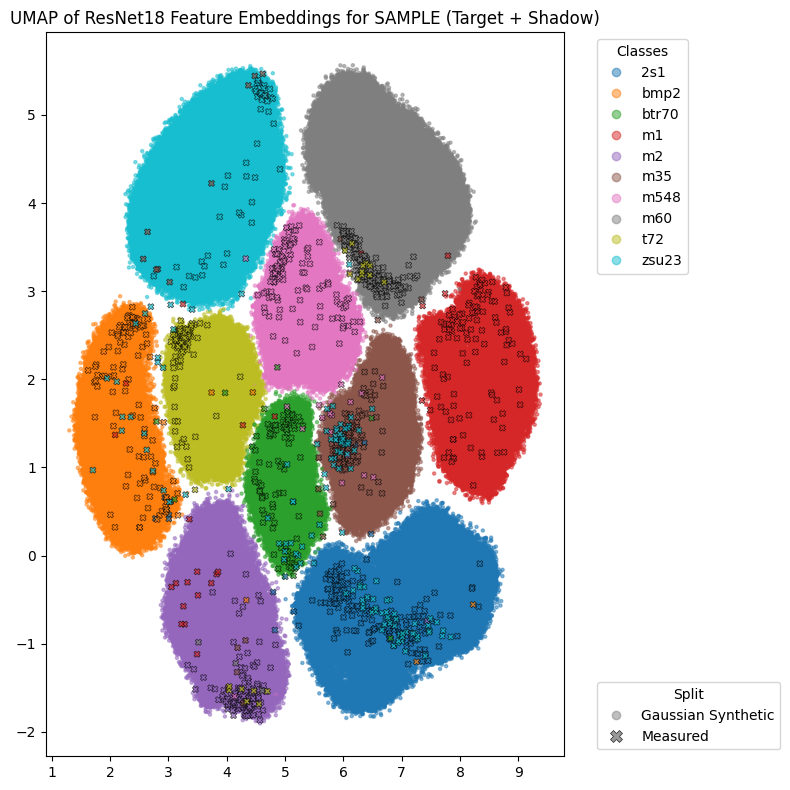

In [10]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

reducer = UMAP(
    n_neighbors=250,
    min_dist=0.25,
    n_components=2,
    metric = "cosine",
)

features_2d = reducer.fit_transform(combined_feats)

# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(SSR_synth_feats), 0],
    features_2d[:len(SSR_synth_feats), 1],
    c=combined_labels[:len(SSR_synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats):, 0],
    features_2d[len(SSR_synth_feats):, 1],
    c=combined_labels[len(SSR_synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Gaussian Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE (Target + Shadow)")
plt.tight_layout()
plt.show()

[2026-05-28 07:41:26.358] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-05-28 07:41:26.359] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-05-28 07:41:26.359] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


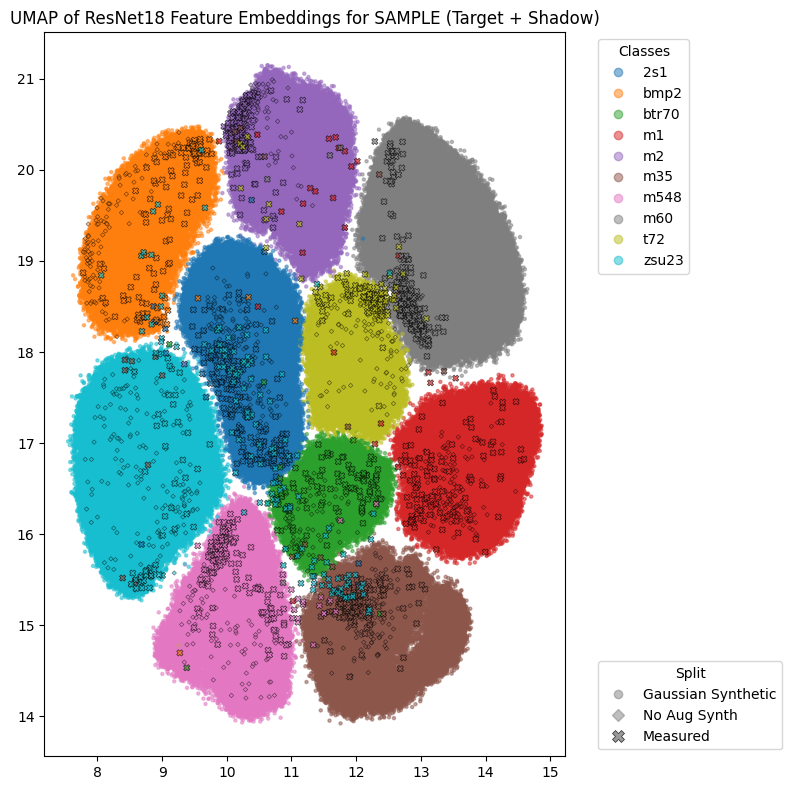

In [11]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, synth_labels, meas_labels], axis=0)

reducer = UMAP(
    n_neighbors=250,
    min_dist=0.25,
    n_components=2,
    metric = "cosine",
)

features_2d = reducer.fit_transform(combined_feats)

# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(SSR_synth_feats), 0],
    features_2d[:len(SSR_synth_feats), 1],
    c=combined_labels[:len(SSR_synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats), 0],
    features_2d[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats), 1],
    c=combined_labels[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    linewidths=0.5,
    marker = "D",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats)+len(synth_feats):, 0],
    features_2d[len(SSR_synth_feats)+len(synth_feats):, 1],
    c=combined_labels[len(SSR_synth_feats)+len(synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Gaussian Synthetic"),
    Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synth"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE (Target + Shadow)")
plt.tight_layout()
plt.show()

## Target Only

### Fill = 0

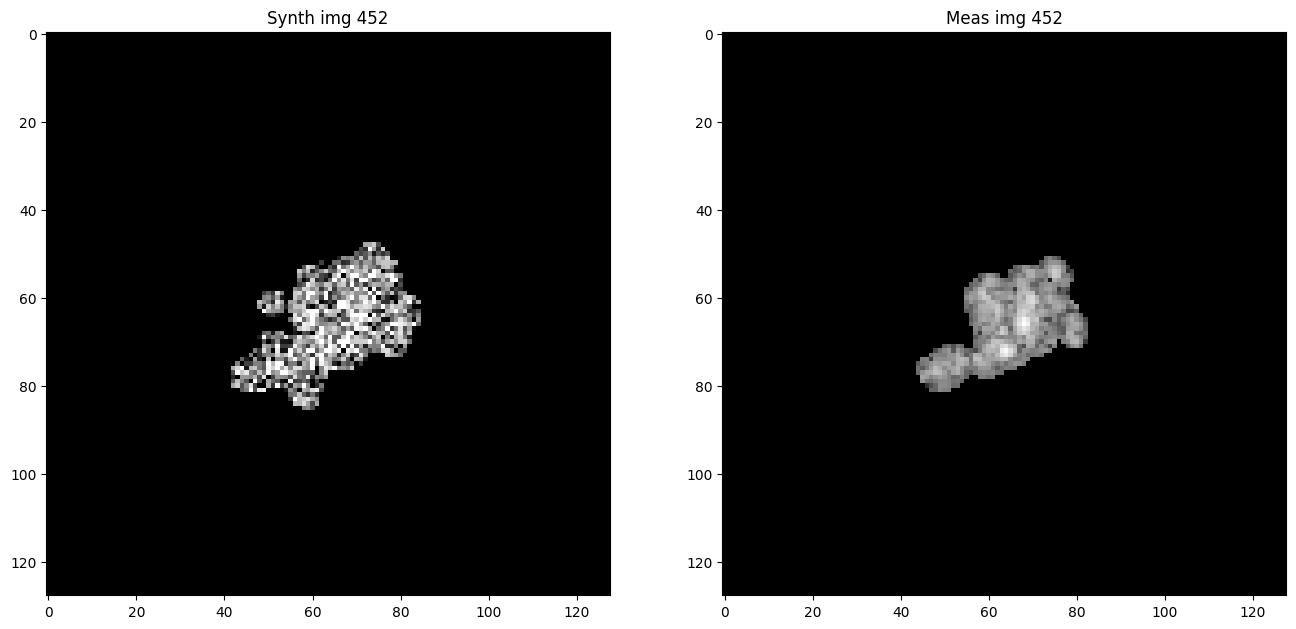

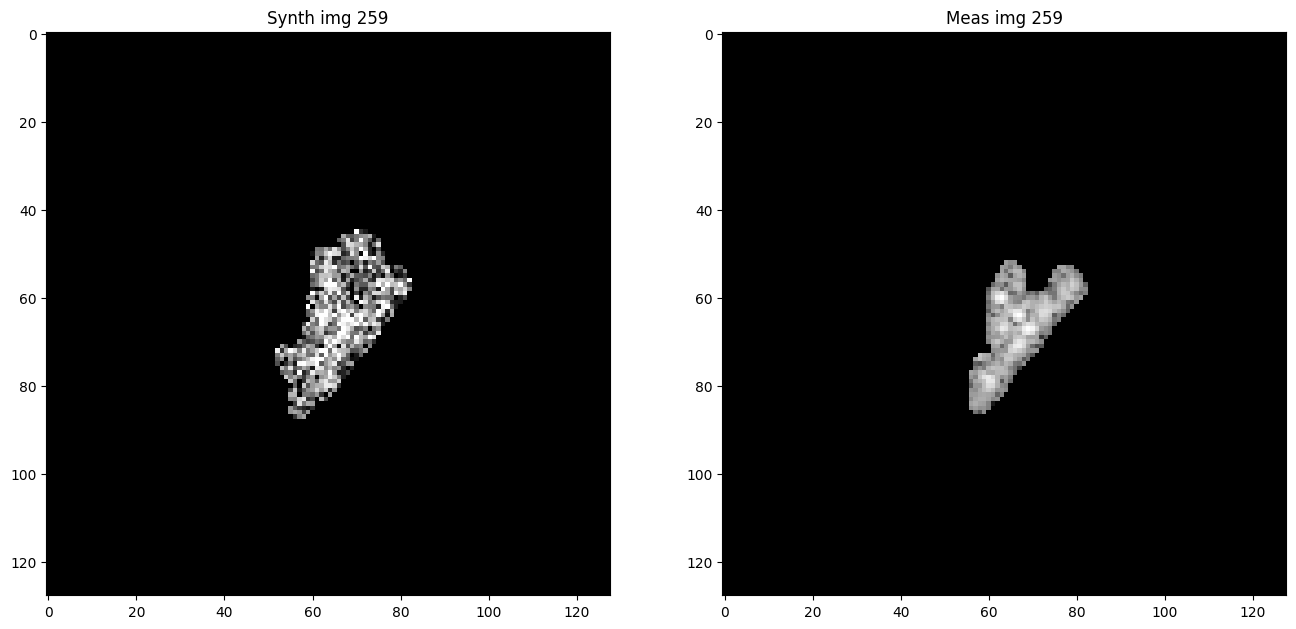

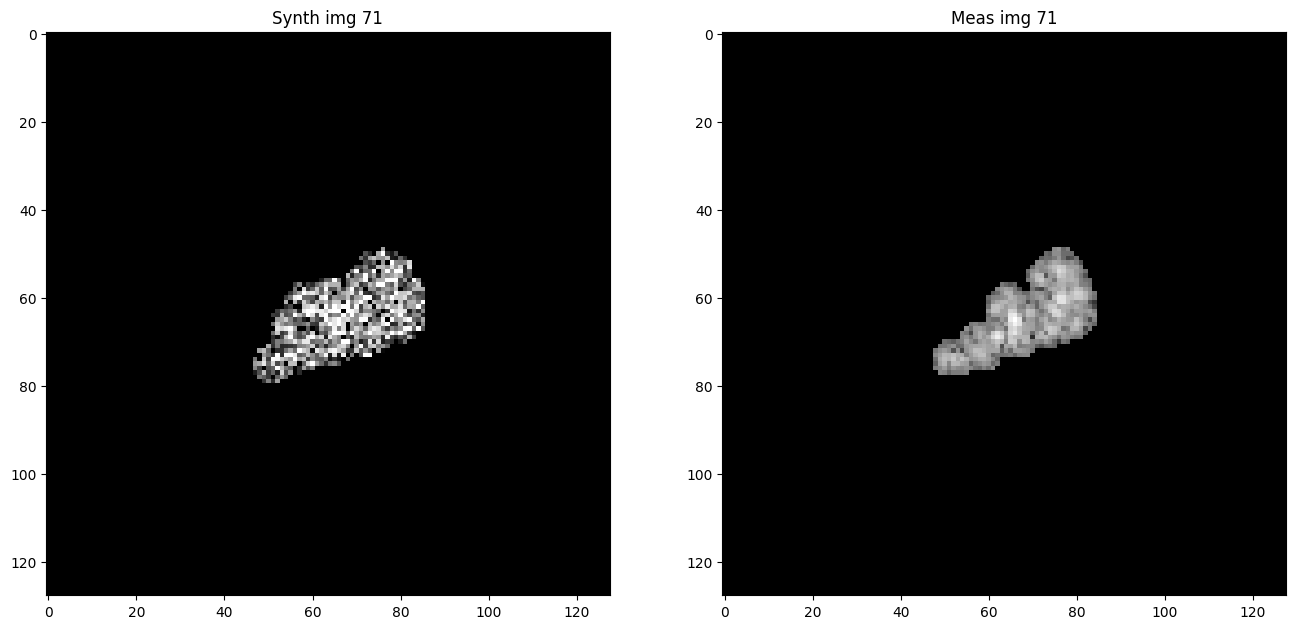

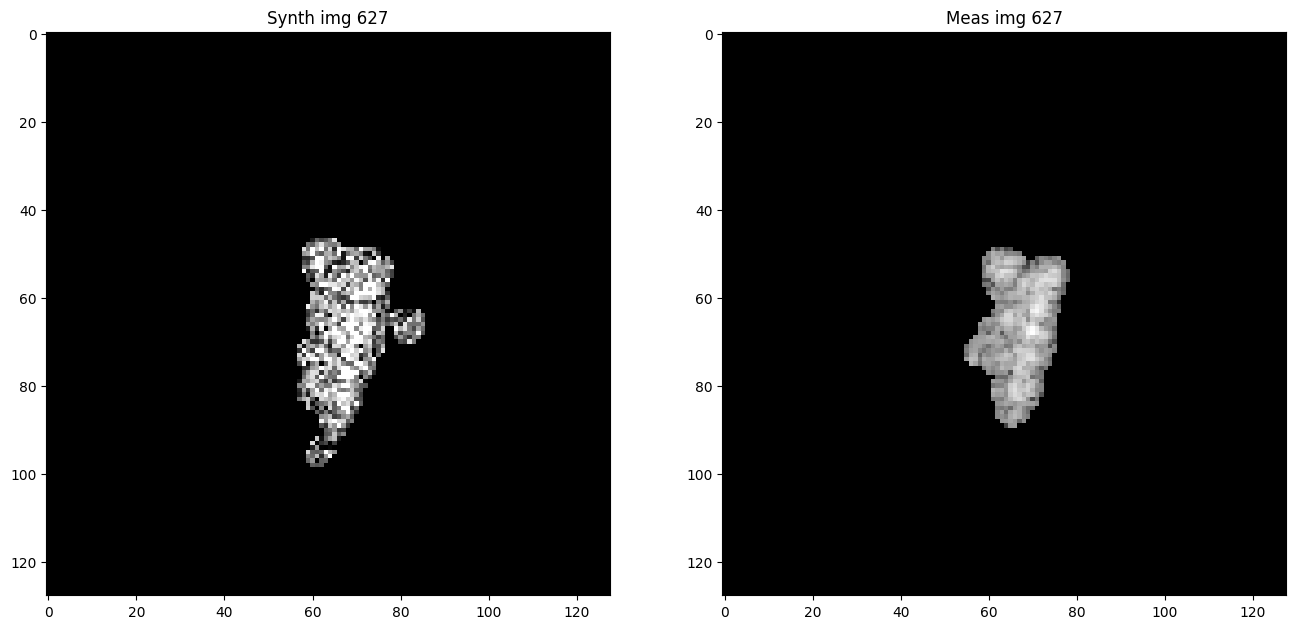

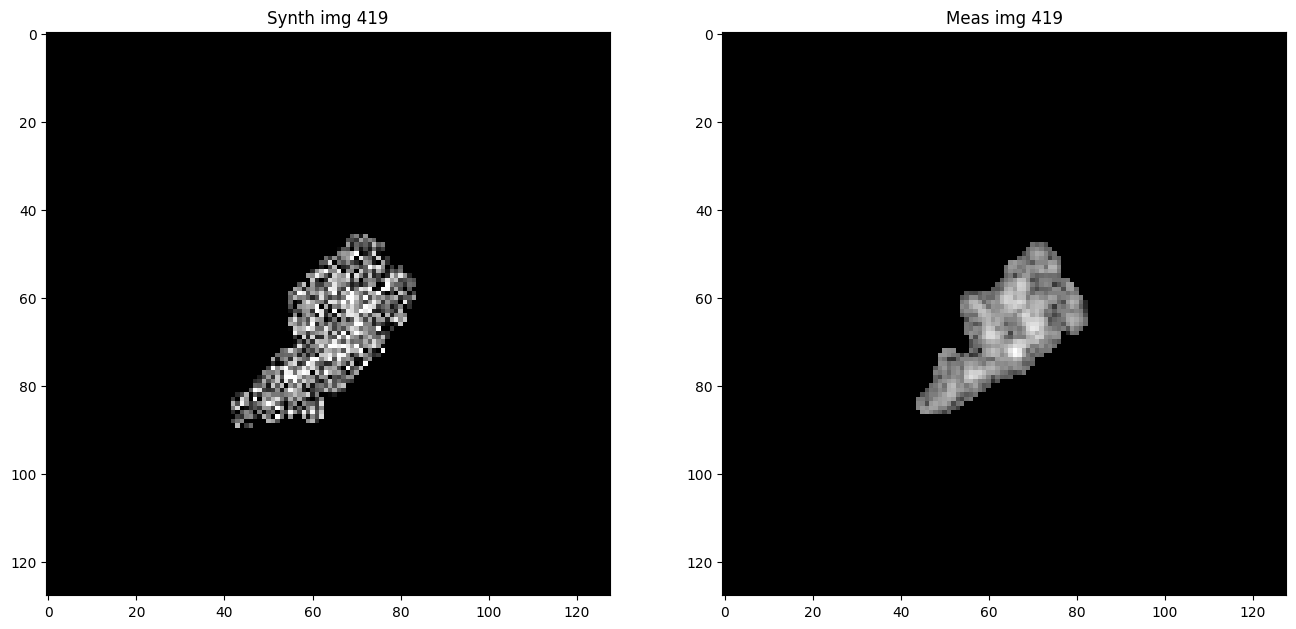

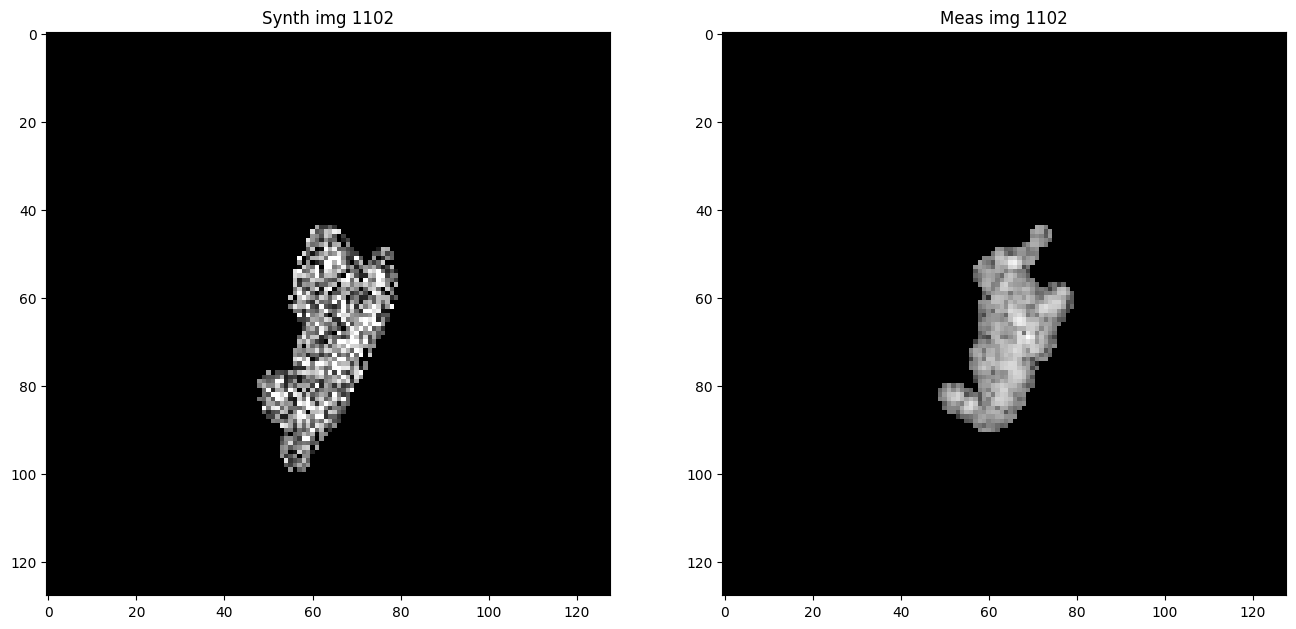

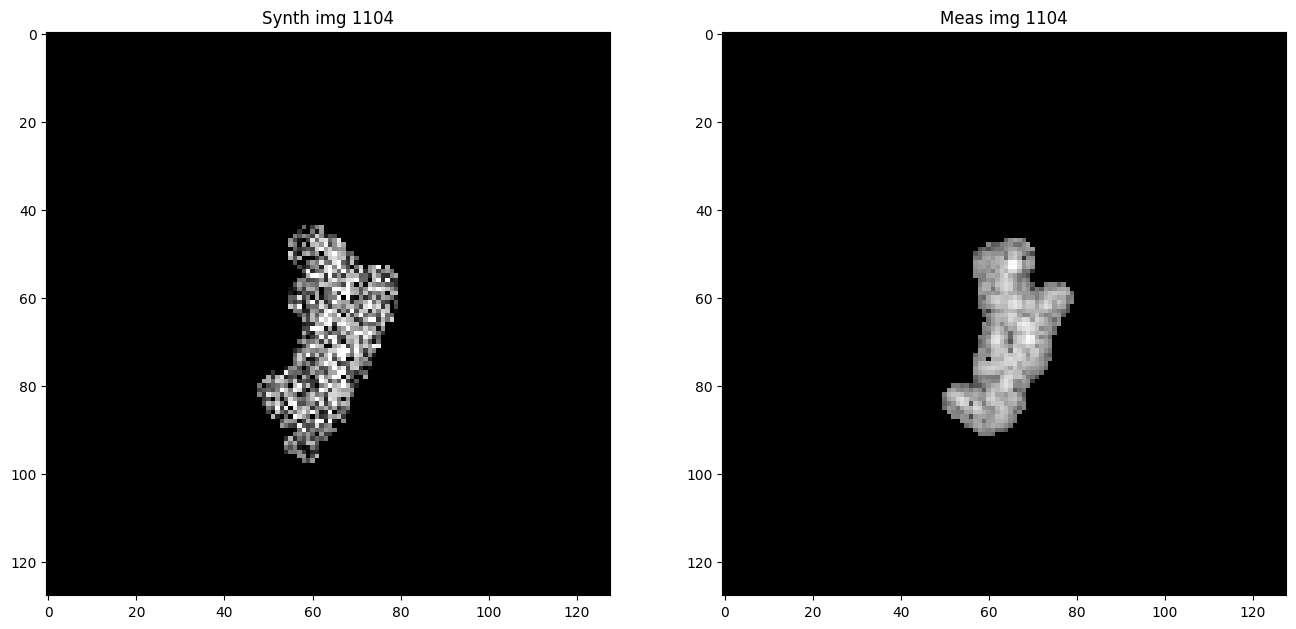

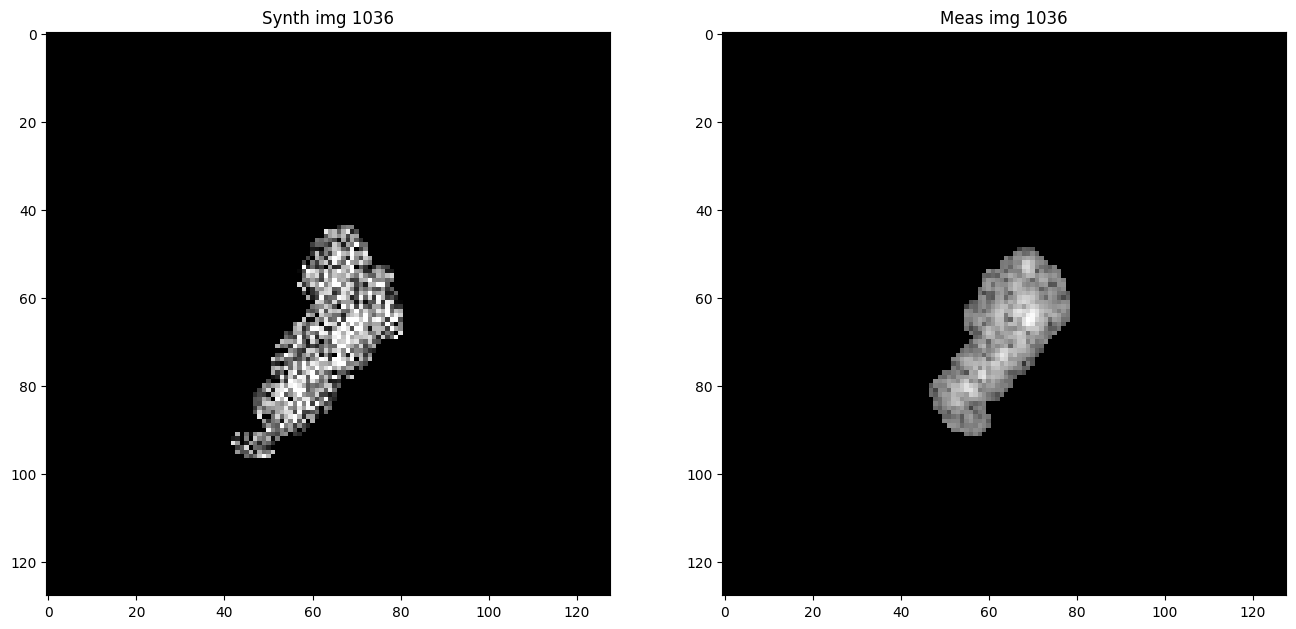

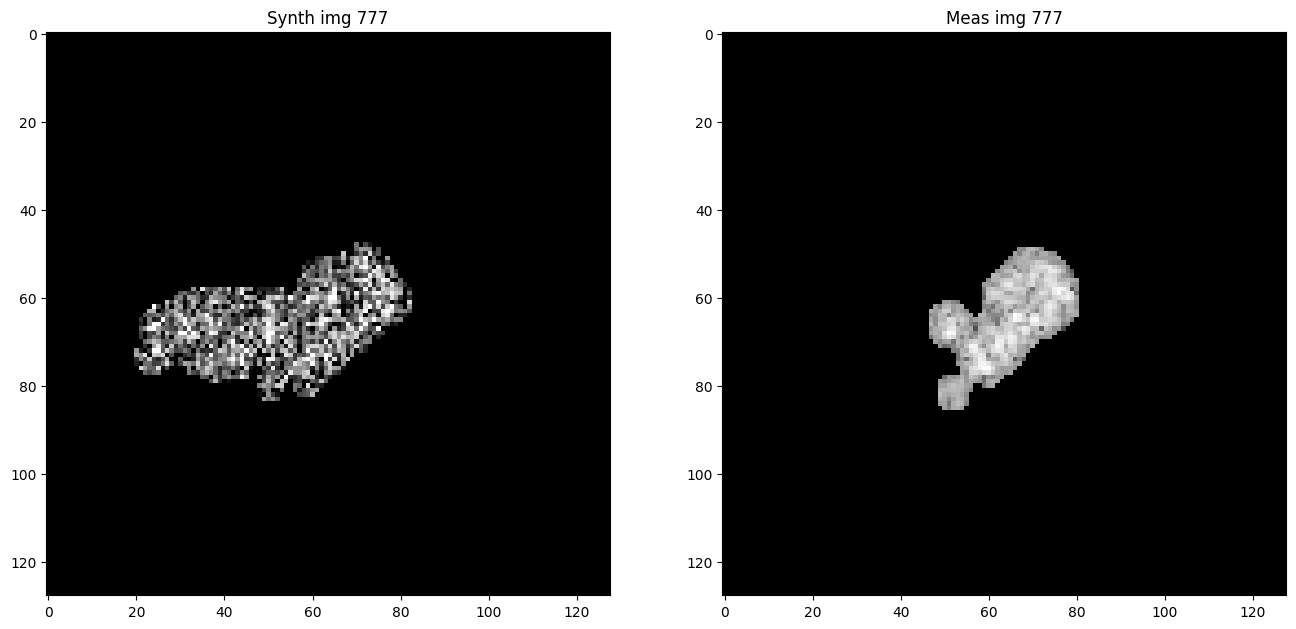

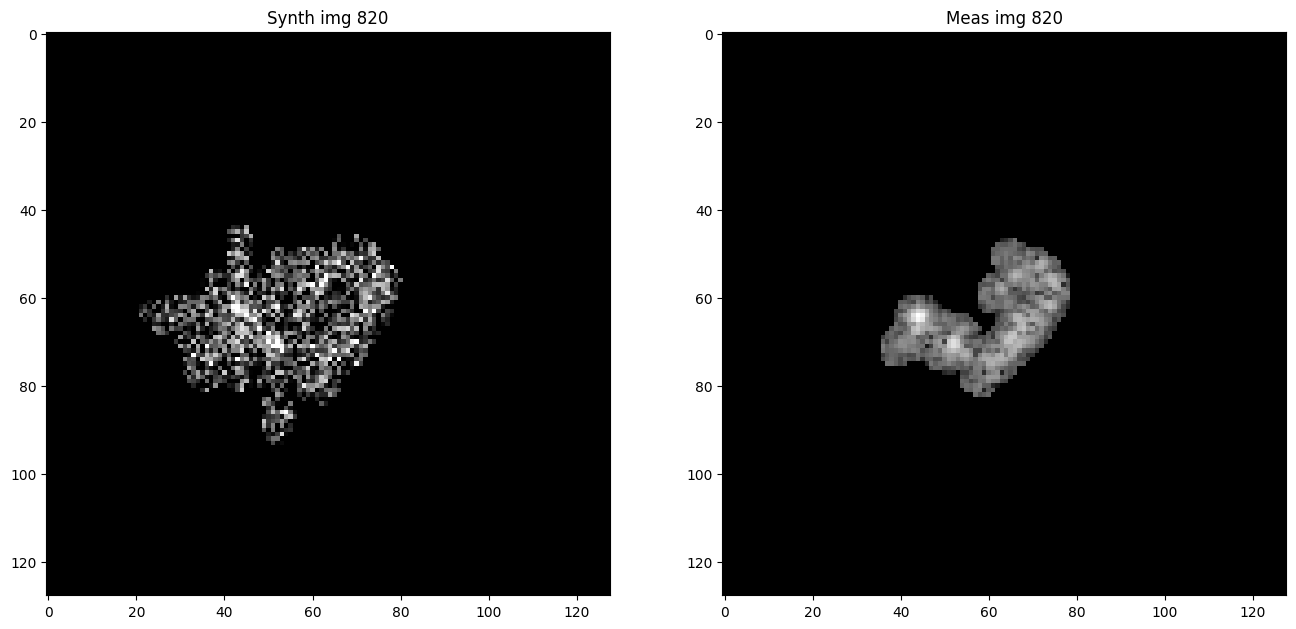

In [9]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = T_synth_ds[i][0][0]
    meas_img = T_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [11]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_only/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(T_meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.7874
Evaluating Run 1: Seed 42
Test Accuracy: 0.7859
Evaluating Run 2: Seed 100
Test Accuracy: 0.7688
Evaluating Run 3: Seed 123
Test Accuracy: 0.7874
Evaluating Run 4: Seed 666
Test Accuracy: 0.8104
Evaluating Run 5: Seed 777
Test Accuracy: 0.7695
Evaluating Run 6: Seed 849
Test Accuracy: 0.7599
Evaluating Run 7: Seed 1000
Test Accuracy: 0.7859
Evaluating Run 8: Seed 1111
Test Accuracy: 0.7918
Evaluating Run 9: Seed 1234
Test Accuracy: 0.7993


In [12]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 75.9851
Max: 81.0409
Avg, Std: 78.4610, 1.4290


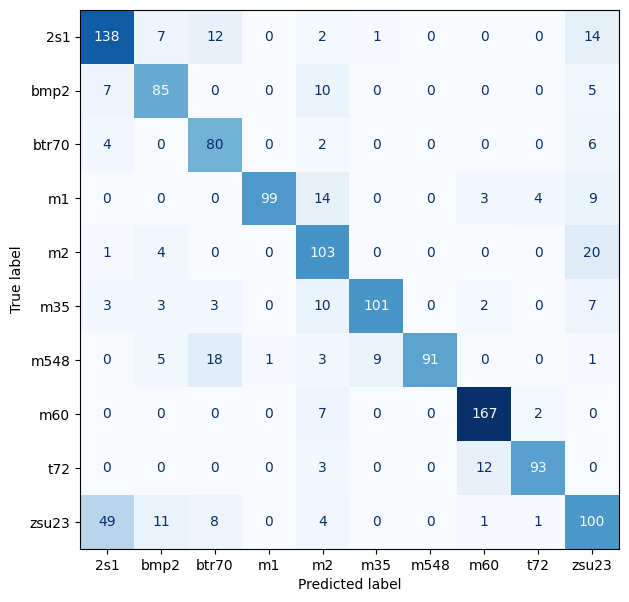

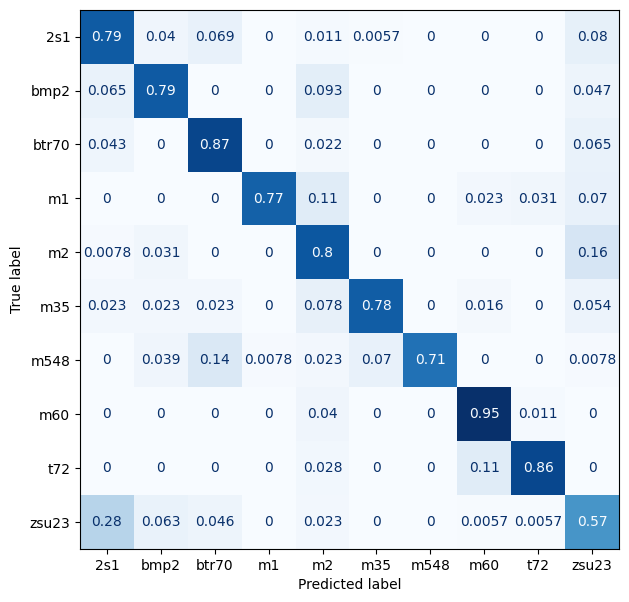

In [11]:
train_ds = T_synth_ds
test_ds = T_meas_ds

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_only/rn18_seed1000_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

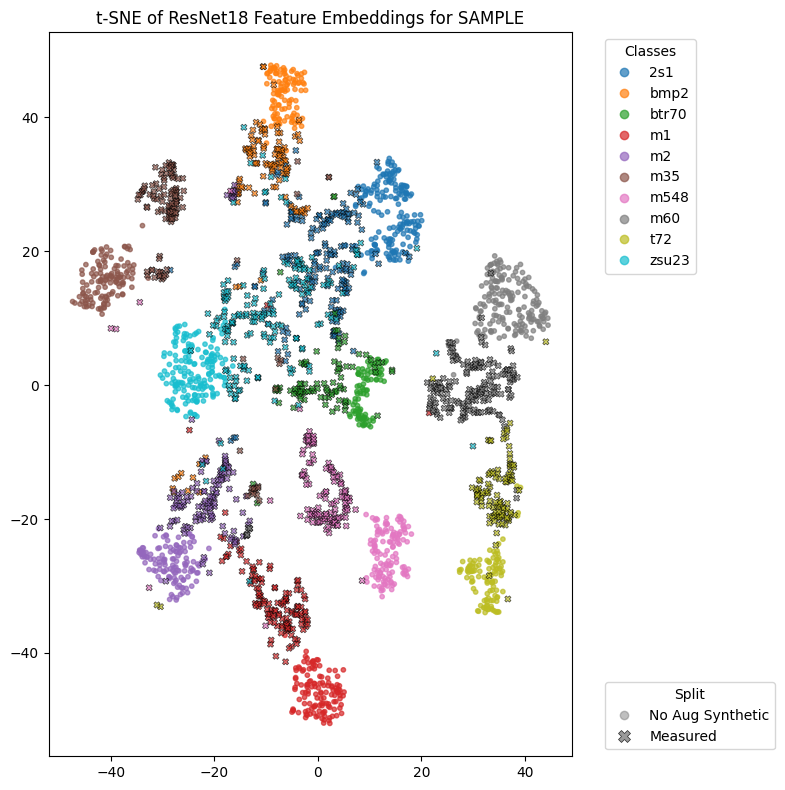

In [12]:
train_ds = T_synth_ds
test_ds = T_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_only/rn18_seed1000_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-27 11:32:21.569] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


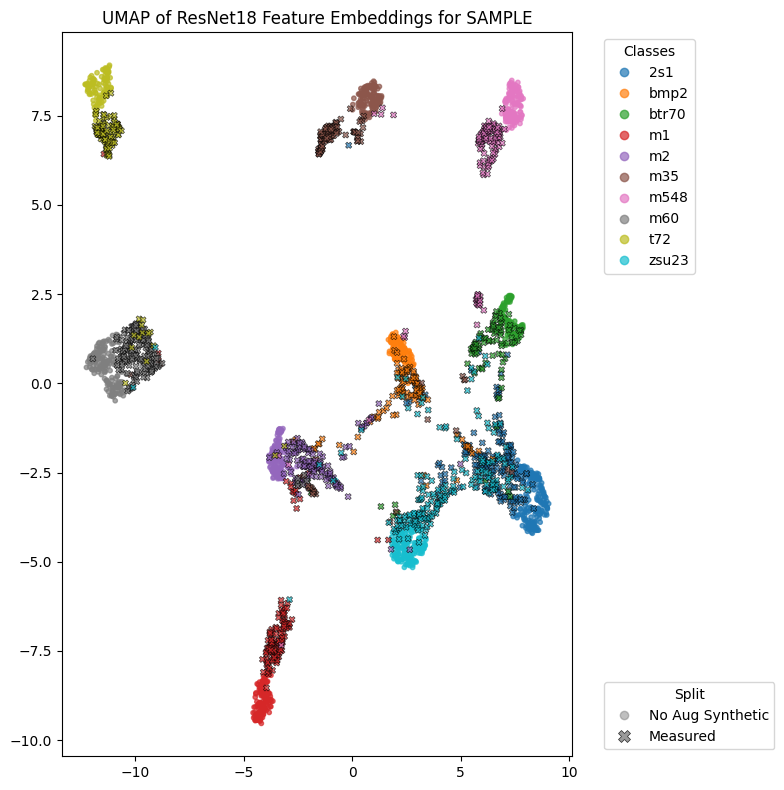

In [13]:
train_ds = T_synth_ds
test_ds = T_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_only/rn18_seed1000_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
    metric = "cosine"
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [12]:
seed = 1000
set_seed(seed)

device = torch.device("cuda:0")
torch.cuda.set_device(device)

# ── Model ────────────────────────────────────────────────────────────────────
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(no_aug_synth_ds.class_to_idx))
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/gaussian_noise/target_only/rn18_seed1000_b16.pth"),
    map_location=device
))
new_model = new_model.to(device).eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1]).to(device).eval()

# ── SSR aug synth — 200 epoch accumulation ───────────────────────────────────
SSR_synth_loader = DataLoader(
    T_synth_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_synth = len(T_synth_ds)
SSR_synth_feats_gpu  = torch.zeros(200 * n_synth, 512, device=device)
SSR_synth_labels_gpu = torch.zeros(200 * n_synth, dtype=torch.long, device=device)

idx = 0
for epoch in tqdm(range(200), leave=False, position=0, desc="Epochs"):
    with torch.no_grad():
        for inputs, targets in tqdm(SSR_synth_loader, leave=False, position=1, desc="Batches"):
            inputs = inputs.to(device)
            feats = feature_extractor(inputs).view(inputs.size(0), -1)
            bs = feats.size(0)
            SSR_synth_feats_gpu[idx:idx+bs]  = feats
            SSR_synth_labels_gpu[idx:idx+bs] = targets.to(device)
            idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

SSR_synth_feats  = SSR_synth_feats_gpu.cpu().numpy()
SSR_synth_labels = SSR_synth_labels_gpu.cpu().numpy()

# ── no aug synth — single pass ───────────────────────────────────────────────────────
synth_loader = DataLoader(
    T_no_aug_synth_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(T_no_aug_synth_ds)
synth_feats_gpu  = torch.zeros(n_no_aug_synth, 512, device=device)
synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(synth_loader, leave=False, position=1, desc="Batches"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        synth_feats_gpu[idx:idx+bs]  = feats
        synth_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

synth_feats  = synth_feats_gpu.cpu().numpy()
synth_labels = synth_labels_gpu.cpu().numpy()

# ── meas — single pass ───────────────────────────────────────────────────────
meas_loader = DataLoader(
    T_meas_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_meas = len(T_meas_ds)
meas_feats_gpu  = torch.zeros(n_meas, 512, device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(meas_loader, leave=False, desc="Meas"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        meas_feats_gpu[idx:idx+bs]  = feats
        meas_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

meas_feats  = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

[2026-05-28 07:52:18.739] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-05-28 07:52:18.741] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-05-28 07:52:18.741] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


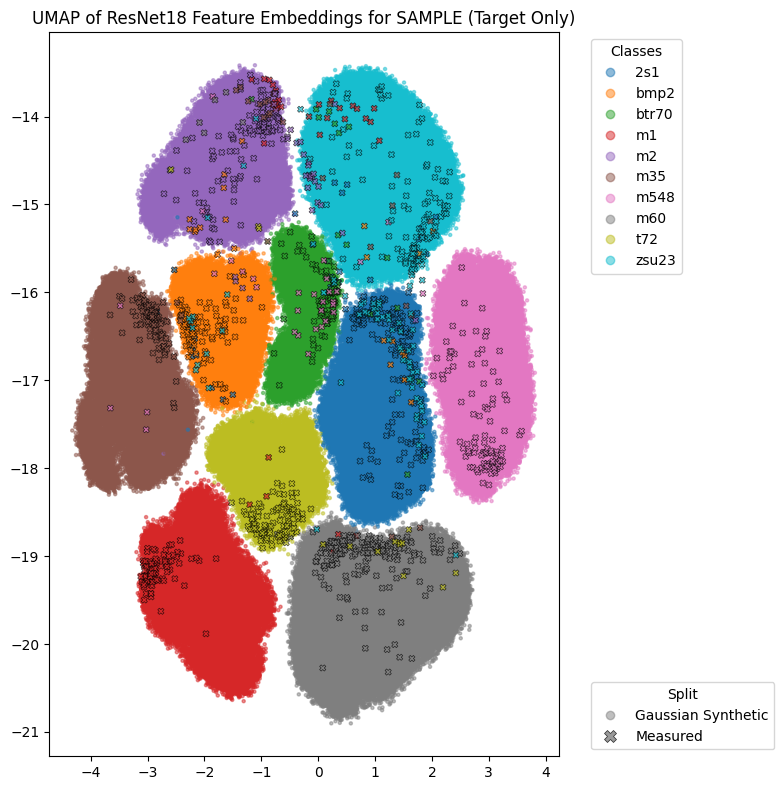

In [13]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

reducer = UMAP(
    n_neighbors=250,
    min_dist=0.25,
    n_components=2,
    metric = "cosine",
)

features_2d = reducer.fit_transform(combined_feats)

# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(SSR_synth_feats), 0],
    features_2d[:len(SSR_synth_feats), 1],
    c=combined_labels[:len(SSR_synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats):, 0],
    features_2d[len(SSR_synth_feats):, 1],
    c=combined_labels[len(SSR_synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Gaussian Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE (Target Only)")
plt.tight_layout()
plt.show()

[2026-05-28 07:52:32.670] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-05-28 07:52:32.672] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-05-28 07:52:32.672] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


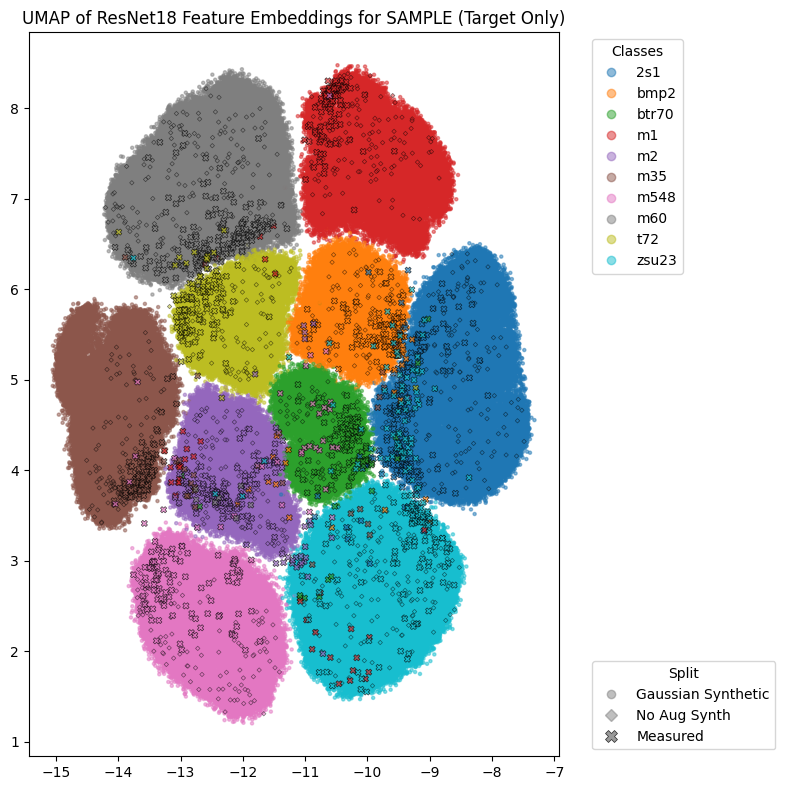

In [14]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, synth_labels, meas_labels], axis=0)

reducer = UMAP(
    n_neighbors=250,
    min_dist=0.25,
    n_components=2,
    metric = "cosine",
)

features_2d = reducer.fit_transform(combined_feats)

# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(SSR_synth_feats), 0],
    features_2d[:len(SSR_synth_feats), 1],
    c=combined_labels[:len(SSR_synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats), 0],
    features_2d[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats), 1],
    c=combined_labels[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    linewidths=0.5,
    marker = "D",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats)+len(synth_feats):, 0],
    features_2d[len(SSR_synth_feats)+len(synth_feats):, 1],
    c=combined_labels[len(SSR_synth_feats)+len(synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Gaussian Synthetic"),
    Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synth"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE (Target Only)")
plt.tight_layout()
plt.show()